# Leap Seconds

In [1]:
import numpy as np
import scipy as sp
import scipy.constants as sc
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

plt.rcParams.update({
    'figure.dpi': 300,
    "font.size": 7,       # base font size
    "axes.labelsize": 8,  # x/y axis labels
    "xtick.labelsize": 7,  # x tick labels
    "ytick.labelsize": 7,  # y tick labels
    "axes.titlesize": 10,  # title
    "legend.fontsize": 7,
})

def seconds_to_hhmm(x, pos):
    total_minutes = round(x / 60)
    hours = total_minutes // 60
    minutes = total_minutes % 60
    return f"{hours:02d}h{minutes:02d}m"

def seconds_to_h(x, pos):
    hours = int(x // 3600)
    return f"{hours:d}h"

def seconds_to_mmss(x, pos):
    minutes = int(x // 60)
    seconds = int(x - minutes * 60)
    return f"{minutes:02d}m{seconds:02d}s"

def day_delta_to24hplusx(sec, pos):
    ms = int(sec*1000)
    if ms > 0:
        return f"24h+{ms:d}ms"
    elif ms < 0:
        return f"24h-{-ms:d}ms"
    else:
        return "24h"

def day_delta_to24hplusmm(sec, pos):
    minutes = int(sec // 60)
    return f"24h{minutes:02d}m"

def moving_average(xs, ys, n=3):
    cs = np.cumsum(ys, dtype=float)
    padded = np.pad(cs, (1,0), mode='constant')
    return xs[n//2-1:-n//2], (padded[n:]-padded[:-n])/n, cs

Length of day increase rate in seconds/year

In [2]:
D = 1.7/1000 / 100  # 1.7 ms per century

In [3]:
D

1.7e-05

In [4]:
def length_of_day_delta(year): return year*D

In [5]:
length_of_day_delta(100) * 365

0.6204999999999999

In [6]:
def t_of_day_shift(year):
    return length_of_day_delta(year) / 2 * year * 365

In [7]:
t_of_day_shift(8000)

198560.0

## Recorded day lengths in the past

In [8]:
from recorded import get_past_lod_deltas
past_times, past_lods, utcdiffs = get_past_lod_deltas()

Text(0.02, 0.0, 'Source: https://hpiers.obspm.fr/eoppc/eop/eopc04/eopc04_IAU2000.62-now')

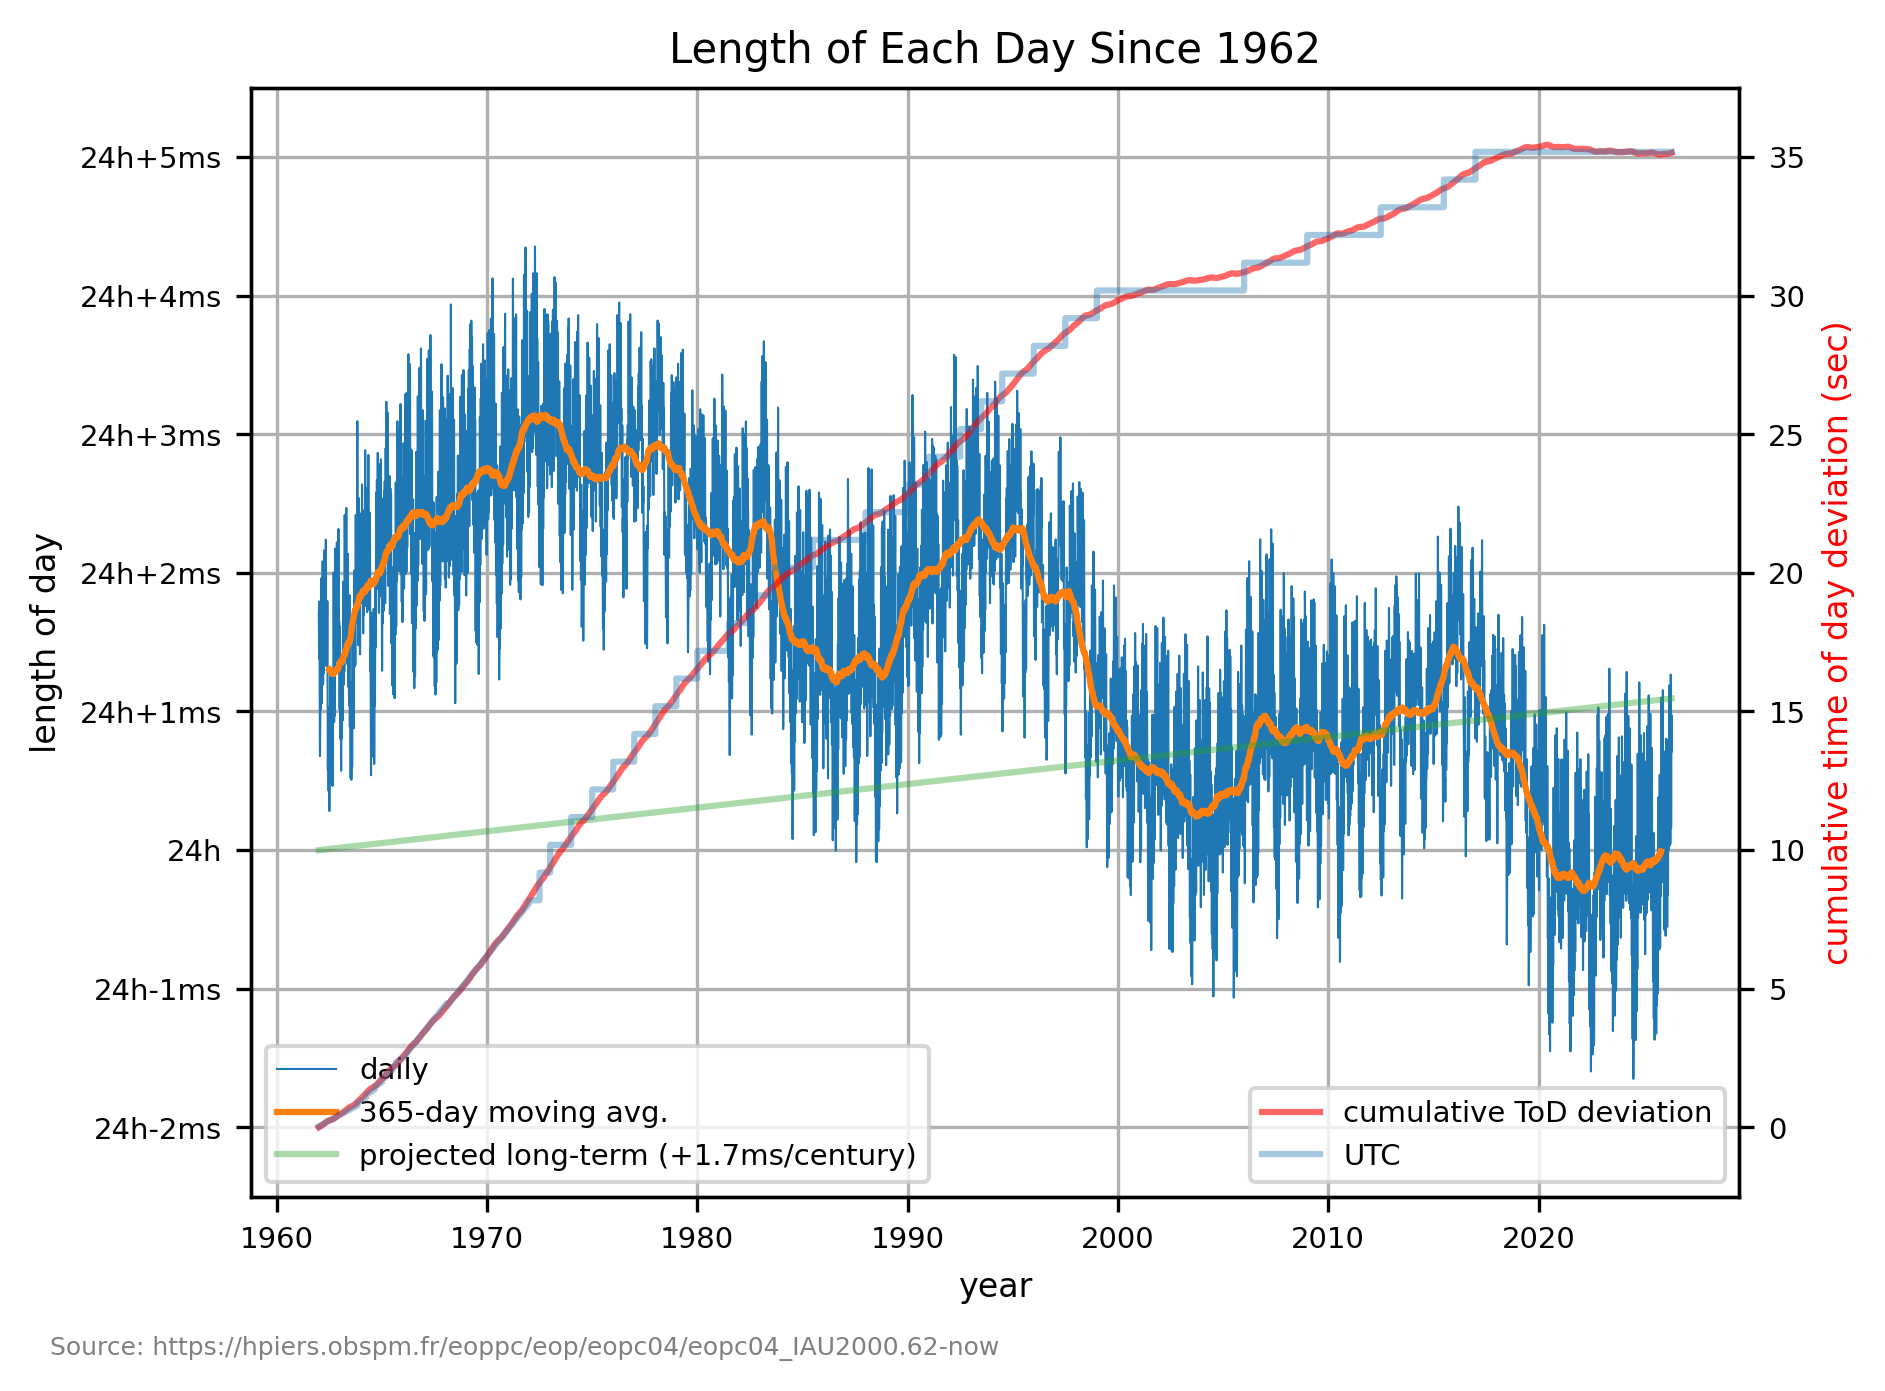

In [19]:
fig, ax = plt.subplots()
ax.plot(past_times, past_lods, lw=0.5, label="daily")
ax.set_title("Length of Each Day Since 1962")

ax.set_xlabel("year")

ax.set_ylabel("length of day")
ax.yaxis.set_major_formatter(FuncFormatter(day_delta_to24hplusx))
ax.yaxis.set_major_locator(MultipleLocator(0.001))
ax.set_ylim(-2.5*0.001, 5.5*0.001)
ax.grid(True)

smoothing_range = 365   # days
past_times_smoothed, past_lods_smoothed, cumsum = moving_average(past_times, past_lods, smoothing_range)
ax.plot(past_times_smoothed, past_lods_smoothed, label=f"{smoothing_range:d}-day moving avg.")

ax.plot(past_times, length_of_day_delta(past_times - past_times[0]) / np.timedelta64(1, 'D') / 365, alpha=.4, label='projected long-term (+1.7ms/century)')

ax2 = ax.twinx()
ax2.plot(past_times, cumsum, 'r-', alpha=.6, label='cumulative ToD deviation')
ax2.plot(past_times, cumsum+utcdiffs, alpha=.4, label='UTC')
ax2.set_ylabel("cumulative time of day deviation (sec)", color='r')
ax2.set_ylim(-2, 38)
## adjust ax2.ylim so two particular points line up horizontally
# y values on ax and ax2 that should line up horizontally
ax_lineup = -2*0.001
ax2_lineup = 0
ax2_height = ax2.get_ylim()[1] - ax2.get_ylim()[0]
ax_height = ax.get_ylim()[1] - ax.get_ylim()[0]
ax2_y0 = ax2_lineup - ax2_height * (ax_lineup - ax.get_ylim()[0]) / ax_height
ax2.set_ylim(ax2_y0, ax2_y0+ax2_height)

ax.legend(loc='lower left')
ax2.legend(loc='lower right')

fig.text(
    0.02, 0.00,
    "Source: https://hpiers.obspm.fr/eoppc/eop/eopc04/eopc04_IAU2000.62-now",
    color="gray", fontsize=6,
)
# TODO maybe ax2 0 should be where the leap seconds start

## Projected leap seconds in the future

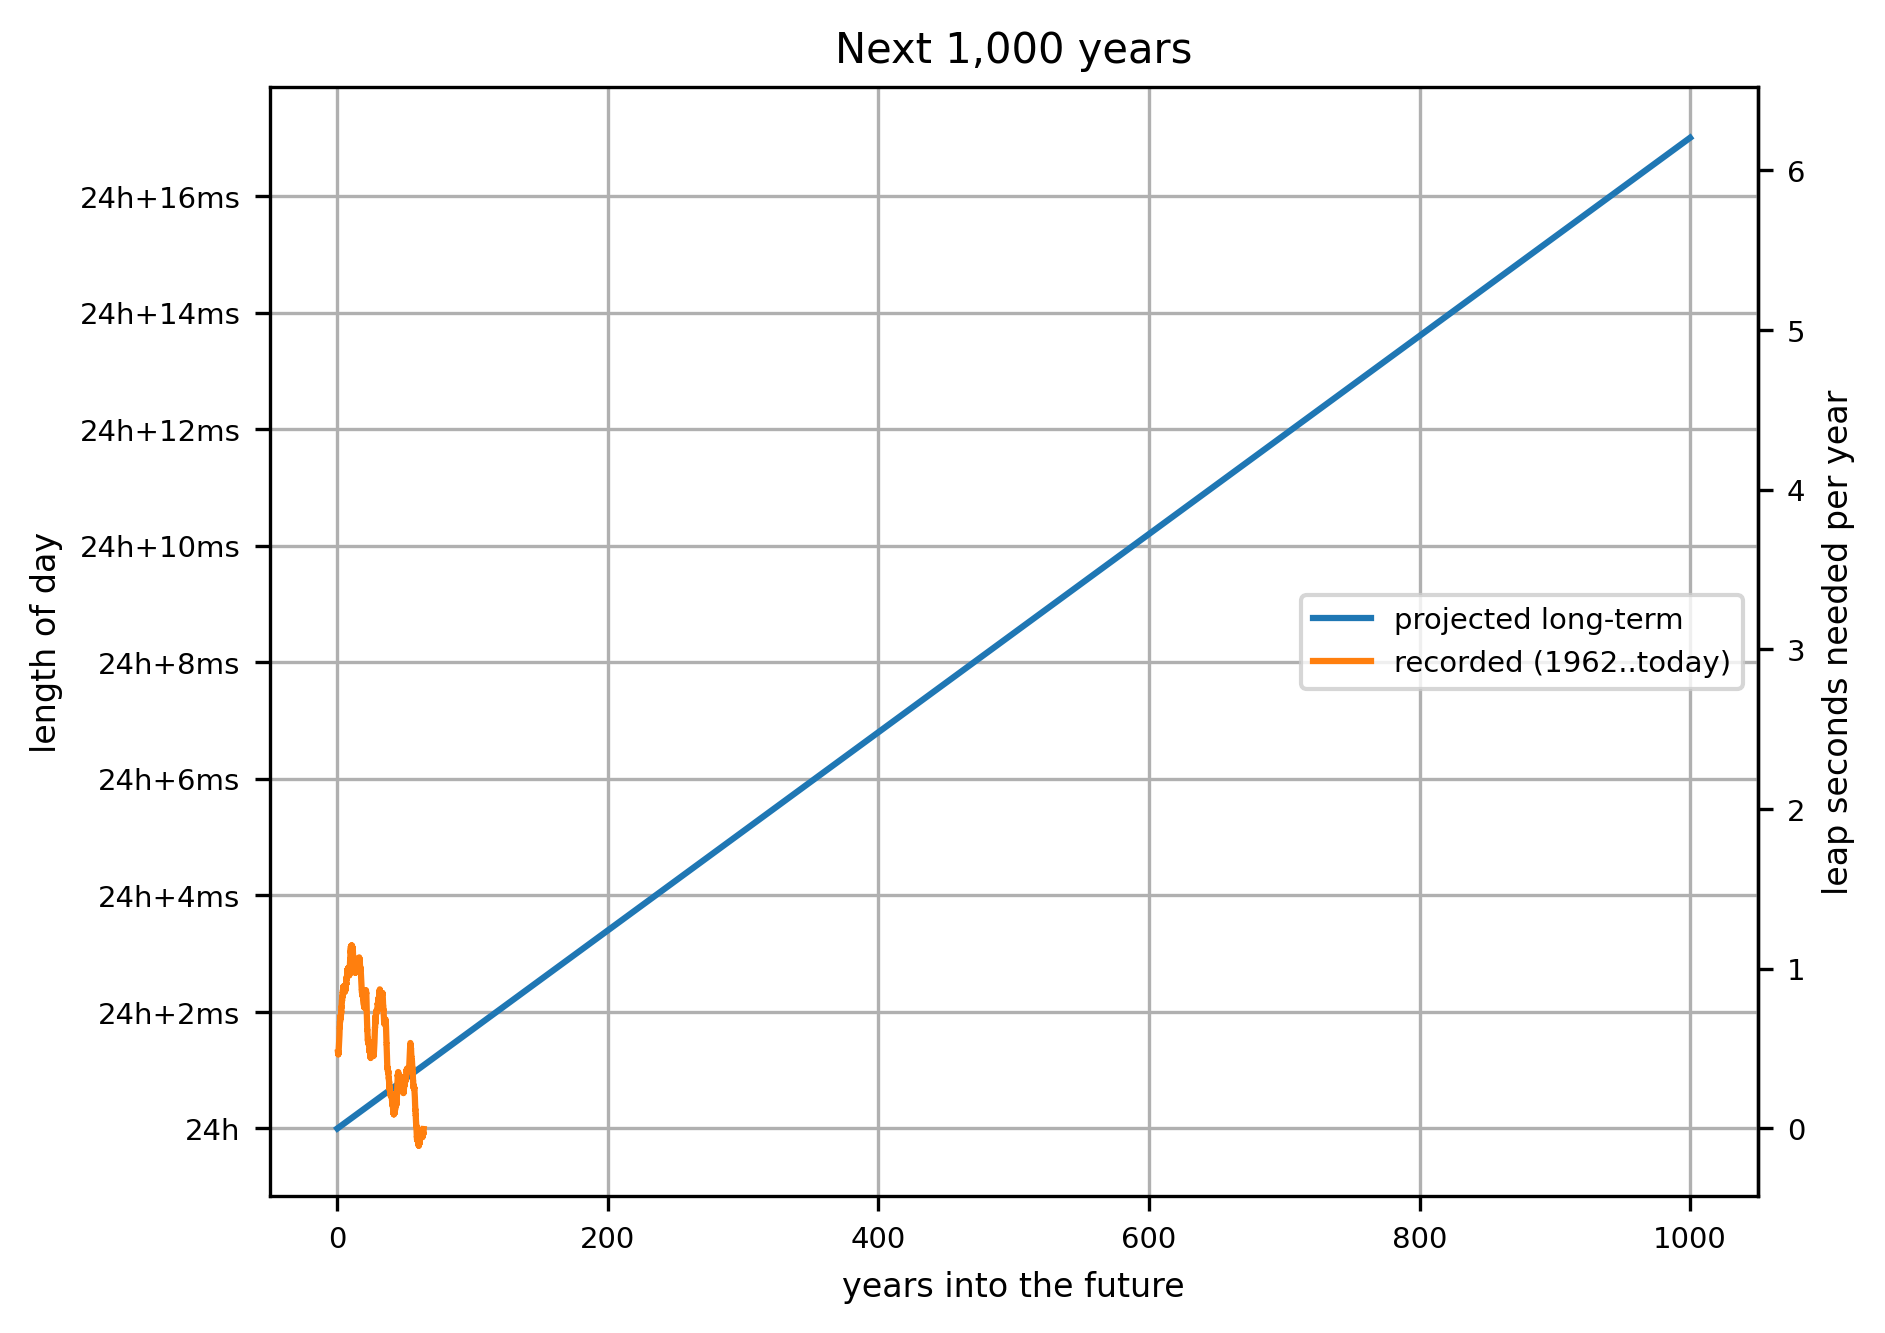

In [10]:
years = np.linspace(0,1000,100)
leapsec_per_year = length_of_day_delta(years) * 365
fig, ax = plt.subplots()
ax.plot(years, length_of_day_delta(years), label='projected long-term')
ax.set_xlabel("years into the future")
ax.set_title("Next 1,000 years")

past_times_smoothed_in_years = (past_times_smoothed - past_times[0]) / np.timedelta64(1, 'D') / 365
ax.plot(past_times_smoothed_in_years, past_lods_smoothed, label='recorded (1962..today)')

ax.set_ylabel("length of day")
ax.yaxis.set_major_formatter(FuncFormatter(day_delta_to24hplusx))
ax.yaxis.set_major_locator(MultipleLocator(0.002))
ax.grid(True)
ax.legend(loc='right')

secax = ax.secondary_yaxis(
    location='right',
    functions=(lambda daylength_delta: daylength_delta/sc.day * sc.year,
               lambda leapsec_per_year: leapsec_per_year/sc.year * sc.day)
)
secax.set_ylabel('leap seconds needed per year')

secax.grid(True)

# TODO added dashed (or half-transparent) plots for the case where the second was defined slightly longer

Text(0, 0.5, 'cumulative time of day deviation')

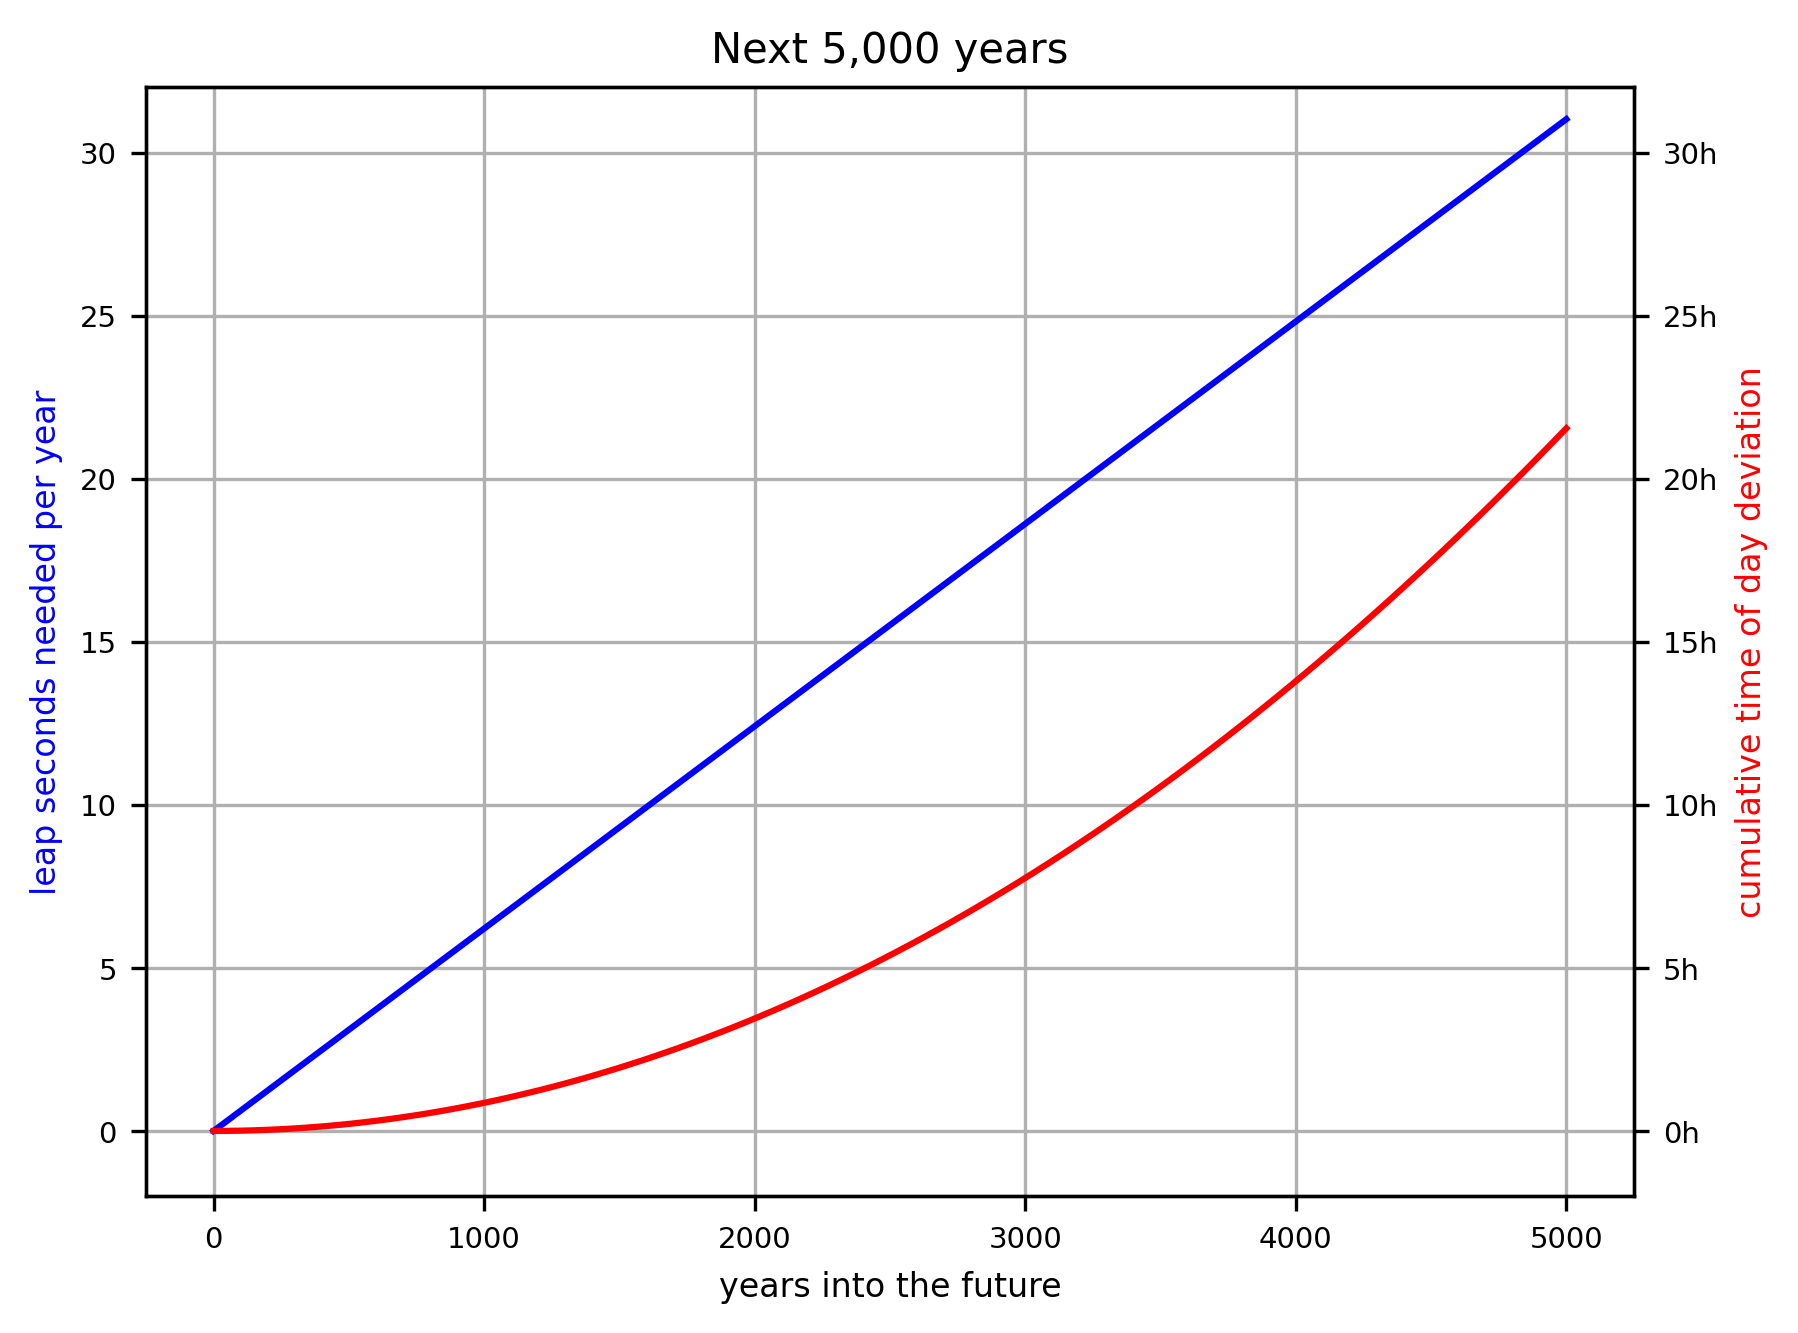

In [11]:
years = np.linspace(0,5000,100)
fig, ax = plt.subplots()
ax.set_title("Next 5,000 years")
ax.plot(years, length_of_day_delta(years) * 365, 'b-')
ax.set_xlabel("years into the future")
ax.set_ylabel("leap seconds needed per year", color='b')
ax.set_ylim(-2, 32)
ax.grid(True)

ax2 = ax.twinx()
ax2.plot(years, t_of_day_shift(years), 'r-')
ax2.yaxis.set_major_formatter(FuncFormatter(seconds_to_h))
ax2.yaxis.set_major_locator(MultipleLocator(5*3600))
ax2.set_ylim(-2*3600, 32*3600)
ax2.set_ylabel("cumulative time of day deviation", color='r')

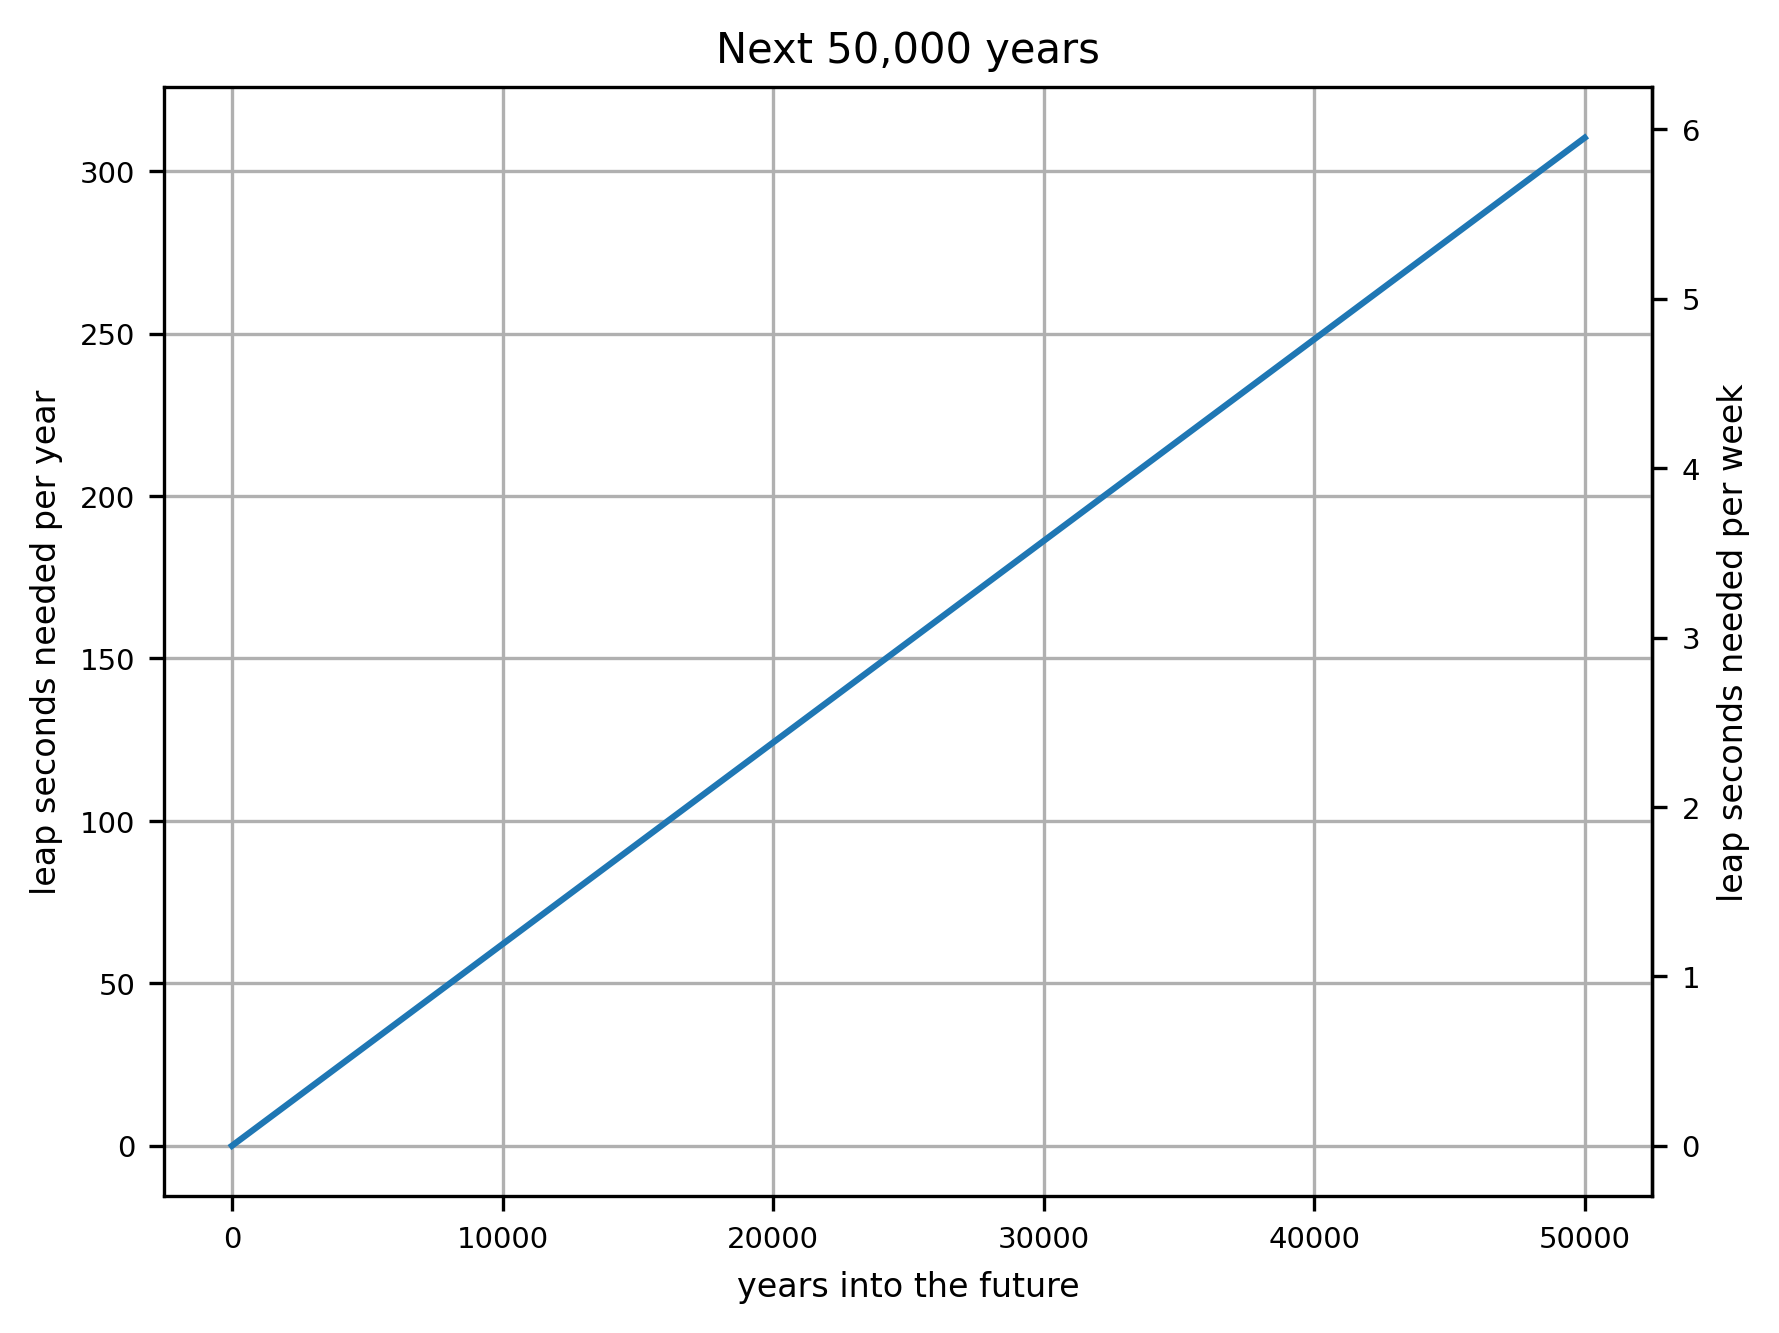

In [12]:
years = np.linspace(0,50000,100)
leapsec_per_year = length_of_day_delta(years) * 365
fig, ax = plt.subplots()
ax.set_title("Next 50,000 years")
ax.plot(years, leapsec_per_year)
ax.set_xlabel("years into the future")
ax.set_ylabel("leap seconds needed per year")
ax.grid(True)
secax = ax.secondary_yaxis(location='right', functions=(lambda year: year*7/365, lambda week: week*365/7))
secax.set_ylabel('leap seconds needed per week')
secax.grid(True)

Text(0, 0.5, 'leap seconds needed per hour')

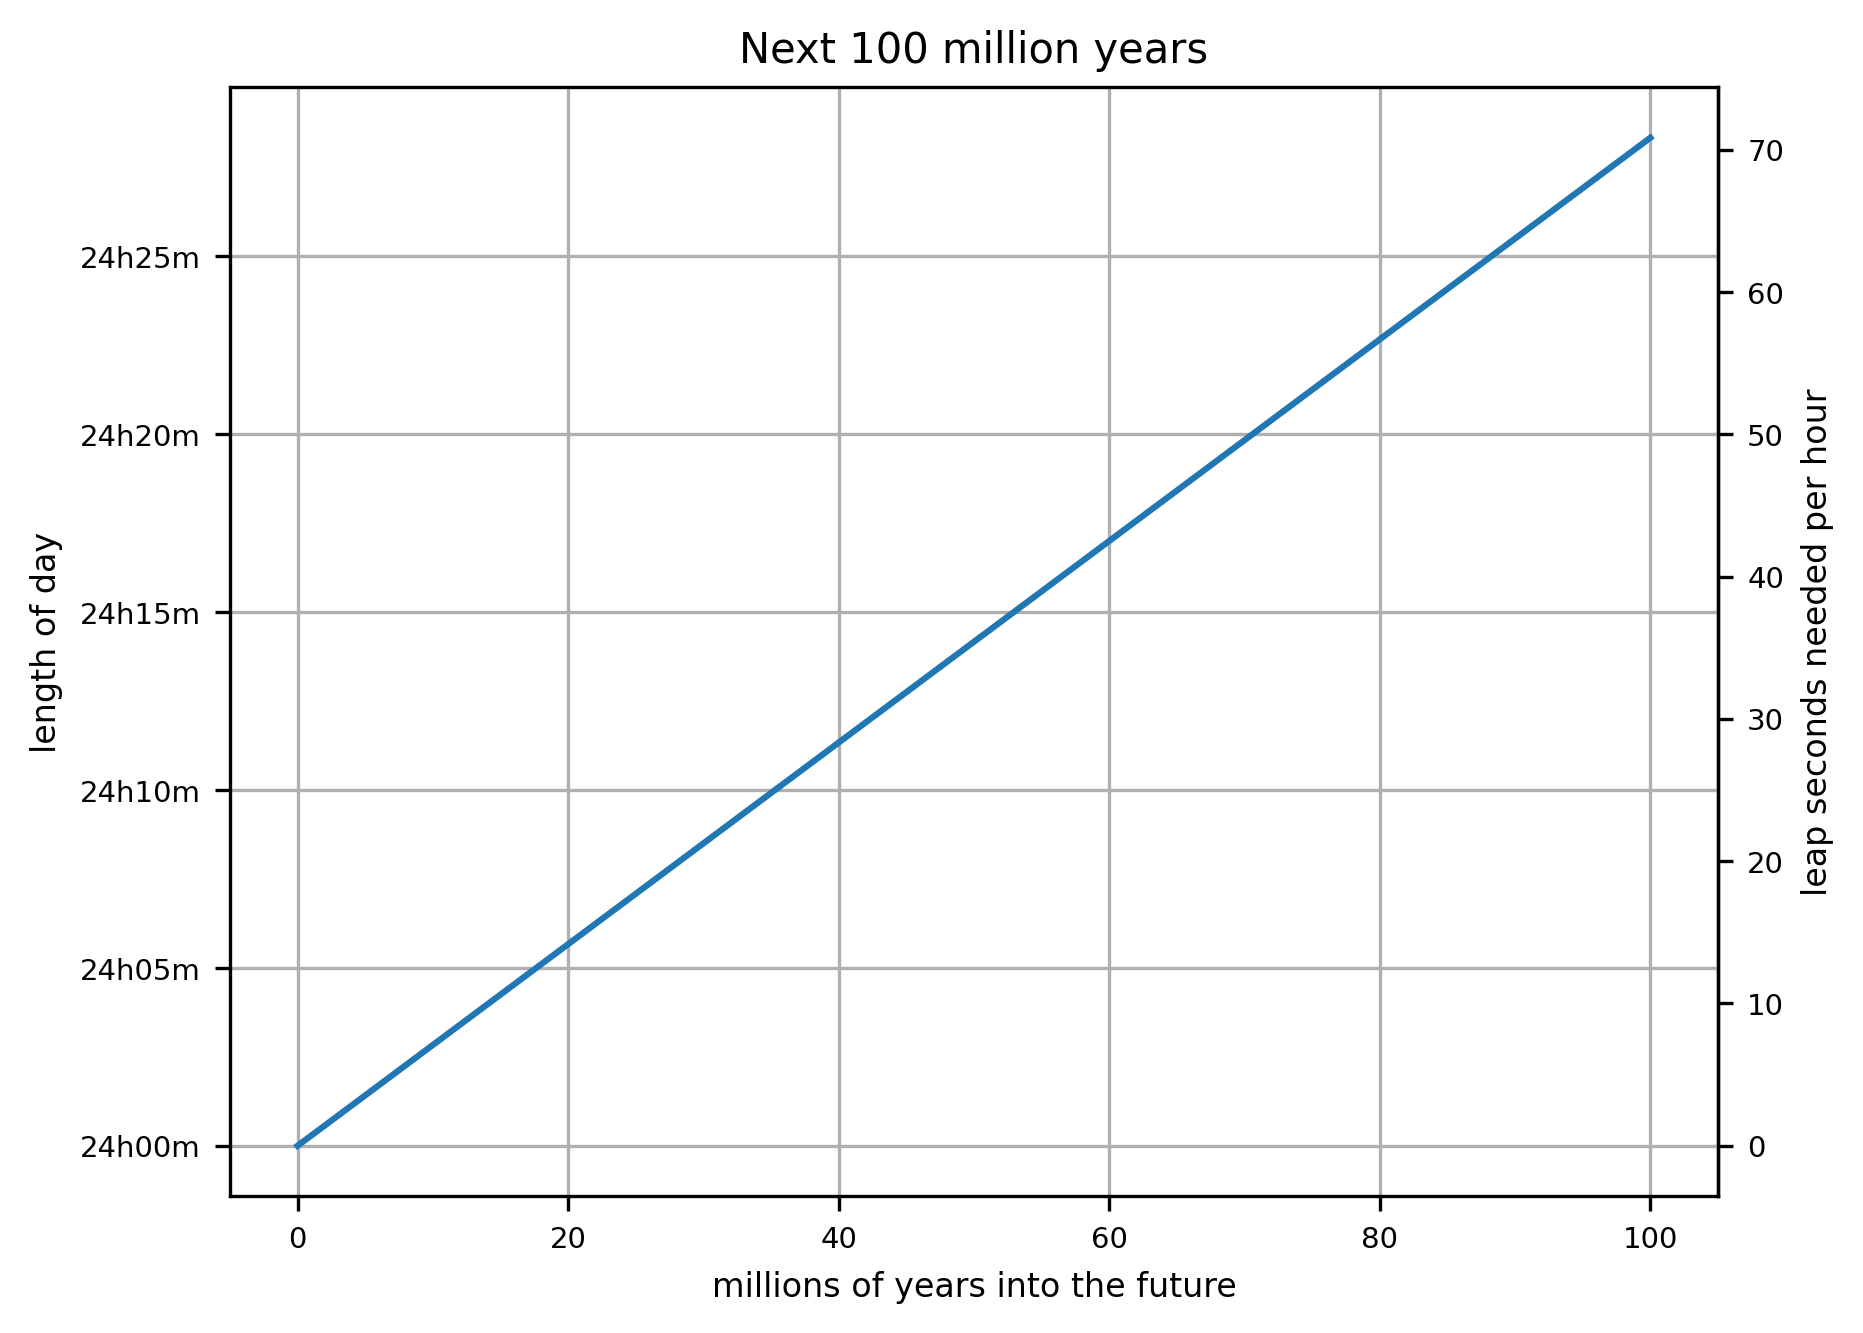

In [13]:
years = np.linspace(0,100e6,100)
leapsec_per_day = length_of_day_delta(years)
fig, ax = plt.subplots()
ax.set_title("Next 100 million years")
ax.plot(years/1e6, leapsec_per_day)
ax.set_xlabel("millions of years into the future")
#ax.set_ylabel("leap seconds needed per day")
ax.set_ylabel('length of day')
ax.yaxis.set_major_formatter(FuncFormatter(day_delta_to24hplusmm))
ax.yaxis.set_major_locator(MultipleLocator(300))
ax.grid(True)
secax = ax.secondary_yaxis(location='right', functions=(lambda lpd: lpd/24, lambda lph: lph*24))
secax.set_ylabel('leap seconds needed per hour')